Using Euler method for calculating differential equations
yi+1 = f(yi,ti)*h + yi

In [34]:
import numpy as np
import matplotlib.pyplot as plt
import math 
def t(x):
    return -x

def f(x):
    return 10*(1-x)*x

x_points = np.linspace(0,1,8)
y_points = f(x_points)
n=8
listY = np.zeros(n)
# y_0 = 10
# listY[0]=y_0
# h = 00.1
# for i in range(1, n):
#     listY[i]=h*f(x_points[i-1]) + listY[i-1]

# print(listY[i])

# plt.plot(x_points, listY)


def euler_method(start, end, y_0, h, f):
    n = math.ceil((end - start) / h)
    x_points = np.linspace(start, end, n)
    
    listY = np.zeros(n)
    listY[0] = y_0

    for i in range(1, n):
        listY[i] = h * f(listY[i - 1]) + listY[i - 1]
        print(listY[i])

euler_method(0,1,0.1,0.01,f)

0.10900000000000001
0.11871190000000001
0.12917383847983901
0.14042263427306137
0.15249304607874892
0.16541693777638627
0.1792223552236932
0.19393252548486975
0.20956479558926278
0.22612953479315212
0.2436290316218906
0.26205642427917764
0.28139470975649655
0.3016158824642519
0.32268025665520816
0.3445360275172219
0.3671191228432093
0.39035339009181347
0.4141511521853777
0.43841414971826786
0.4630348680227755
0.4878982259245661
0.5128835806309888
0.5378669819660014
0.56272359113368
0.5873301662452095
0.6115675104515679
0.6353227795127319
0.6584915540472267
0.6809795967767962
0.702704235331847
0.7235953346297002
0.7435958472628834
0.7626619535825112
0.7807628233965331
0.7978800470963738
0.81400679485056
0.8291467681293279
0.8433130086323297
0.8565266264427115
0.8688155029064494
0.8802130153880356
0.8907568216809894
0.9004877323119665
0.9094486899387284
0.9176838669694743
0.925237885696817
0.9321551597536271
0.9384793515434587
0.9442529373704616
0.9495168701342332
0.9543103284807055
0.95

In [50]:
def alpha_n(V):
    return 0.01*(10 - V)/(np.exp(1-V/10)-1)
    
def beta_n(V):
    return 0.125*np.exp(-V/80)

def alpha_m(V):
    return 0.1*(25 - V)/(np.exp((25-V)/10)-1)
    
def beta_m(V):
    return 4.0*np.exp(-V/18)
    
def alpha_h(V):
    return 0.07*np.exp(-V/20)

def beta_h(V):
    return 1/(np.exp((30-V)/10) + 1)


In [ ]:
gNa=1.2
ENa=55.17
gK=0.36
Ek= -72.14
gl=0.003
El= -49.42
Iext=6
c=0.01 
#- constants
def Iion(V,n,m,h):
    return gNa*m**3*h*(V-ENa) + gK*n**4*(V-Ek) + gl*(V-El)

def dV_dt(V,n,m,h,Iext):
    return 1/c*(Iext - Iion(V,n,m,h))
    
def dn_dt(n, V):
    return alpha_n(V)*(1-n) - beta_n(V)*n

def dm_dt(m, V):
    return alpha_m(V)*(1-m) - beta_m(V)*m

def dh_dt(h, V):
    return alpha_h(V)*(1-h) - beta_h(V)*h

def function(vec, Iext):
    return np.array([dV_dt(vec[0], vec[1], vec[2], vec[3], Iext), dn_dt(vec[1], vec[0]), dm_dt(vec[2], vec[0]), dh_dt(vec[3], vec[0])])

def euler_method_HH_model(start, end, step, I_EXT):
    # t_points = np.array([np.linspace(start, end, N) for i in range(4)]).T
    # print(t_points)
    
    N = math.ceil((end - start)/step)
    x = np.linspace(start, end, N)
    
    listY = np.zeros([N, 4])
    listY[0] = [-70,0,0,1]
    print(N)
    for i in range(1,N):
        
        Iext = I_external(i*h)
        listY[i] = listY[i-1] + step*function(listY[i-1], Iext)
    # print(t_points[0])
    plt.plot(x, listY.T[0], label=f"Iext - {Iext}")
    # plt.plot(x, listY.T[1], label=f"N - {Iext}")
    # plt.plot(x, listY.T[2], label=f"M - {Iext}")
    # plt.plot(x, listY.T[3], label=f"H - {Iext}")
    
euler_method_HH_model(0, 200, 0.0001, 70)
# euler_method_HH_model(0, 100, 0.001, 70)
# euler_method_HH_model(0, 5, 100, 0.01, 5)
# euler_method_HH_model(0, 5, 100, 0.01, 55)
# euler_method_HH_model(0, 5, 100, 0.01, 66)
plt.legend()
plt.show()


2000000


In [99]:
def I_external(t):
    if t <= 1:
        return 1000
    return 0

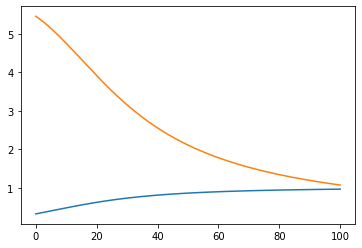

In [8]:
def n_infinity(Vc):
    return alpha_n(Vc)/(alpha_n(Vc) + beta_n(Vc))

def tau(Vc):
    return 1/(alpha_n(Vc) + beta_n(Vc))

Vc = np.linspace(0, 100, 1000)

plt.plot(Vc, n_infinity(Vc))
plt.plot(Vc, tau(Vc))

plt.show()

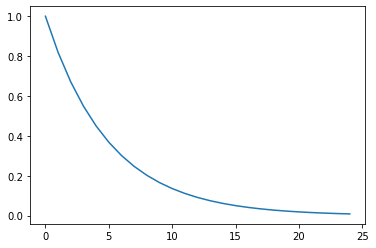

In [74]:
from scipy.integrate import odeint
x0 = 1
t_start = 0
t_stop = 25
increment = 1

t = np.arange(t_start, t_stop, increment)
def myDiff(x, t):
    a = -1/5
    dx_dt = x * a
    return dx_dt

x = odeint(myDiff, x0, t)
plt.plot(t, x)

In [ ]:

def euler_method_backward_HH_model(start, end, step, Iext):
    # t_points = np.array([np.linspace(start, end, N) for i in range(4)]).T
    # print(t_points)
    
    N = math.ceil((end - start)/step)
    x = np.linspace(start, end, N)
    
    listY = np.zeros([N, 4])
    listY[0] = [1,0,0,1]
    print(N)
    for i in range(1,N):
       
        listY[i] = listY[i-1] + step*function(listY[i-1], Iext)
    # print(t_points[0])
    plt.plot(x, listY.T[0], label=f"Iext - {Iext}")

euler_method_HH_model(0, 0.5, 0.001, 70)